# ARTI-308: Lab 4 – Data Quality Assessment & Preprocessing

This notebook covers **Data Quality Assessment and Preprocessing** as part of **Lab 4** for the  
**ARTI-308 Machine Learning** course.

The goal of this lab is to evaluate the quality of the dataset and prepare it for machine learning models.  
This includes identifying issues such as missing values, duplicates, data type inconsistencies, and outliers, then applying appropriate preprocessing techniques.

The dataset used is the **Breast Cancer dataset**, where the target variable is **Status** (Alive or Dead).

![Breast Cancer](Breast_Cancer_img.png)

## 1. Import Required Libraries

In [209]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler # for feature scaling
from sklearn.decomposition import PCA # for dimensionality reduction if needed

## 2. Load the Dataset

In [210]:
# Load the dataset
C_df = pd.read_csv("Breast_Cancer.csv")

C_df.head() # display first 5 rows

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


## 3. Data Overview

In [211]:
# Display the shape
C_df.shape

(4024, 16)

In [212]:
# Display all column names
C_df.columns

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='object')

In [213]:
# Displays the data types of all features in the dataset
C_df.dtypes

Age                        int64
Race                      object
Marital Status            object
T Stage                   object
N Stage                   object
6th Stage                 object
differentiate             object
Grade                     object
A Stage                   object
Tumor Size                 int64
Estrogen Status           object
Progesterone Status       object
Regional Node Examined     int64
Reginol Node Positive      int64
Survival Months            int64
Status                    object
dtype: object

All data types appear appropriate and do not require conversion.

## 4. Data Quality Assessment

In [214]:
# Check missing values
C_df.isnull().sum()  # count missing values in each column

Age                       0
Race                      0
Marital Status            0
T Stage                   0
N Stage                   0
6th Stage                 0
differentiate             0
Grade                     0
A Stage                   0
Tumor Size                0
Estrogen Status           0
Progesterone Status       0
Regional Node Examined    0
Reginol Node Positive     0
Survival Months           0
Status                    0
dtype: int64

No missing values were found in the dataset.

In [215]:
# Check duplicate rows
C_df.duplicated().sum()  # count duplicate rows

np.int64(1)

One duplicate record was found in the dataset.

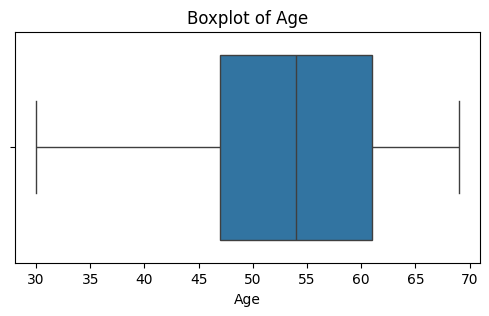

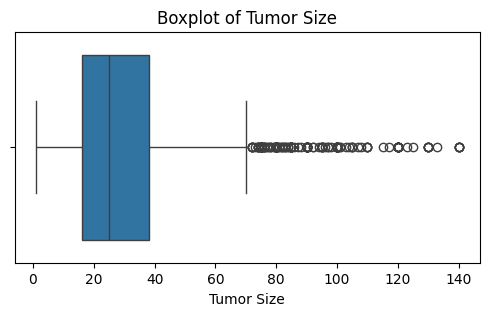

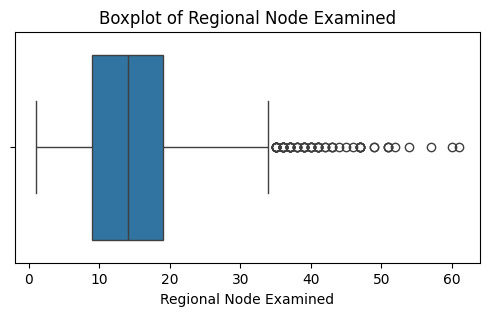

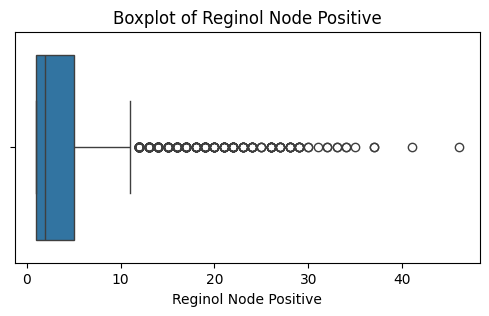

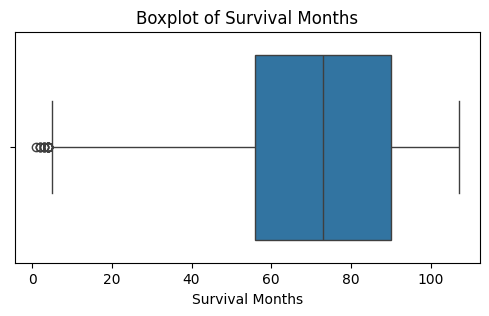

In [216]:
# Select numerical columns
numerical_cols = ["Age", "Tumor Size", "Regional Node Examined", "Reginol Node Positive", "Survival Months"]

# Boxplots for numerical features to check outliers 
for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=C_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Outliers were detected in some numerical features and will be handled using IQR clipping.

## 5. Data Cleaning

In [217]:
# Remove duplicate rows
C_df = C_df.drop_duplicates()

In [218]:
# Verify that no duplicate records remain after removing duplicates
C_df.duplicated().sum()

np.int64(0)

In [219]:
# Check dataset shape after removing duplicates
C_df.shape

(4023, 16)

In [220]:
# Remove extra spaces from column names
C_df.columns = C_df.columns.str.strip()

In [221]:
# Handle outliers using IQR clipping
outlier_cols = ["Tumor Size", "Regional Node Examined", "Reginol Node Positive", "Survival Months"]

for col in outlier_cols: 
    Q1 = C_df[col].quantile(0.25)  # calculate 25th percentile
    Q3 = C_df[col].quantile(0.75)  # calculate 75th percentile
    IQR = Q3 - Q1  # compute interquartile range
    
    lower_bound = Q1 - 1.5 * IQR  # define lower limit for outliers
    upper_bound = Q3 + 1.5 * IQR  # define upper limit for outliers
    
    C_df[col] = C_df[col].clip(lower=lower_bound, upper=upper_bound)  # cap values within bounds

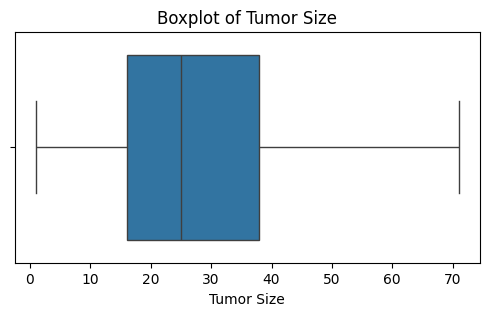

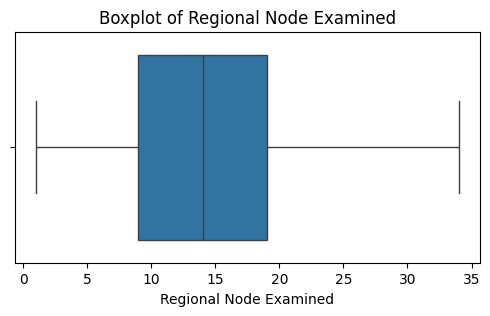

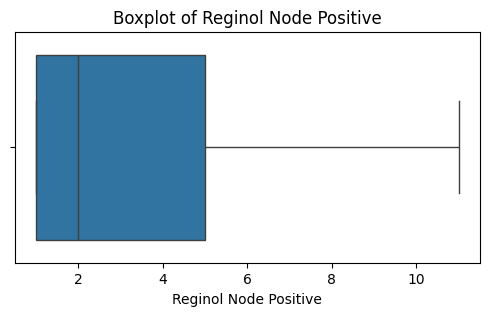

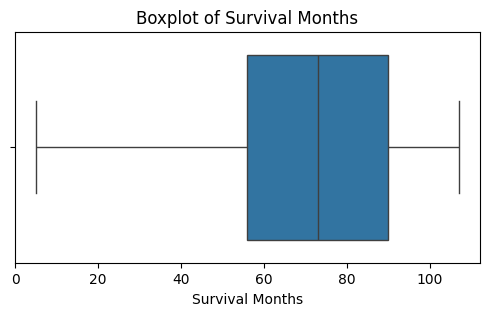

In [222]:
# Boxplots after outlier handling
for col in outlier_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=C_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## 6. Data Transformation – Normalization

In [223]:
# Before scaling
C_df[numerical_cols].head()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
0,68,4,24,1,60
1,50,35,14,5,62
2,58,63,14,7,75
3,58,18,2,1,84
4,47,41,3,1,50


In [224]:
# Create copies for scaling
C_df_minmax = C_df[numerical_cols].copy()
C_df_standard = C_df[numerical_cols].copy()

In [225]:
# Min-Max Scaling
minmax_scaler = MinMaxScaler()
C_df_minmax[numerical_cols] = minmax_scaler.fit_transform(C_df_minmax) # scale values between 0 and 1

C_df_minmax.head()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
0,0.974359,0.042857,0.696970,0.0,0.539216
1,0.512821,0.485714,0.393939,0.4,0.558824
2,0.717949,0.885714,0.393939,0.6,0.686275
3,0.717949,0.242857,0.030303,0.0,0.774510
4,0.435897,0.571429,0.060606,0.0,0.441176


In [226]:
# Z-score Standardization
standard_scaler = StandardScaler()
C_df_standard[numerical_cols] = standard_scaler.fit_transform(C_df_standard) # center data around mean = 0

C_df_standard.head()

,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
0,1.565507,-1.427103,1.273211,-0.782858,-0.493918
1,-0.442973,0.317782,-0.029897,0.436318,-0.406572
2,0.449685,1.893808,-0.029897,1.045907,0.161176
3,0.449685,-0.639090,-1.593627,-0.782858,0.554233
4,-0.777719,0.655502,-1.463316,-0.782858,-0.930647


## 7. Data Reduction Analysis – PCA

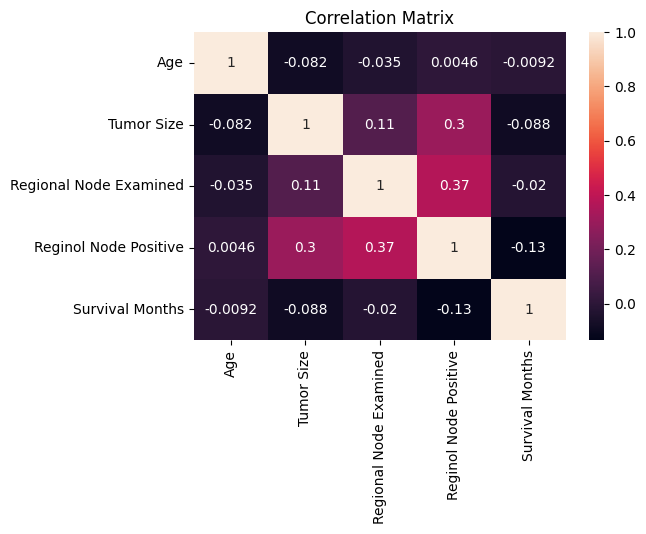

In [227]:
# Correlation Matrix
corr_matrix = C_df[numerical_cols].corr()

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

Based on the correlation heatmap, the relationships between the numerical features are **weak.** Therefore, applying PCA is not necessary in this case.